# Optimal K-Nearest Neighbors (KNN) for Steel Faults Classification

This notebook demonstrates an optimal workflow for classifying steel faults using a K-Nearest Neighbors (KNN) classifier. It incorporates best practices for machine learning, including data loading, preprocessing, integrated feature selection, and hyperparameter tuning using scikit-learn pipelines and GridSearchCV to ensure fair and robust results.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

## Setup Output Directory for Plots

Creates a directory named `plots` to save generated visualizations.

In [2]:
# ==============================================================================
# Setup Output Directory for Plots
# ==============================================================================
os.makedirs("plots", exist_ok=True)

## 1. Load Dataset

The dataset `Faults.csv` is loaded. If the file is not found locally, it will be downloaded from the UCI Machine Learning Repository.

In [3]:
# ==============================================================================
# 1. Load Dataset (from file if exists, else download from UCI)
# ==============================================================================
file_path = os.path.join("data/data", "Faults.csv")

if os.path.exists(file_path):
    print("Loading dataset from local directory.")
    steel_data = pd.read_csv(file_path)
else:
    print("Dataset not found. Downloading from UCI repository.")
    dataset = fetch_ucirepo(id=198)
    steel_data = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
    os.makedirs("data/data", exist_ok=True)
    steel_data.to_csv(file_path, index=False)

Loading dataset from local directory.


## 2. Quick Dataset Overview

Provides a summary of the dataset, including descriptive statistics, the first few rows, and information about data types and non-null values. Visualizations of fault class distribution are also generated.


--- Data Summary ---
         X_Minimum    X_Maximum     Y_Minimum     Y_Maximum   Pixels_Areas  \
count  1941.000000  1941.000000  1.941000e+03  1.941000e+03    1941.000000   
mean    571.136012   617.964451  1.650685e+06  1.650739e+06    1893.878413   
std     520.690671   497.627410  1.774578e+06  1.774590e+06    5168.459560   
min       0.000000     4.000000  6.712000e+03  6.724000e+03       2.000000   
25%      51.000000   192.000000  4.712530e+05  4.712810e+05      84.000000   
50%     435.000000   467.000000  1.204128e+06  1.204136e+06     174.000000   
75%    1053.000000  1072.000000  2.183073e+06  2.183084e+06     822.000000   
max    1705.000000  1713.000000  1.298766e+07  1.298769e+07  152655.000000   

        X_Perimeter   Y_Perimeter  Sum_of_Luminosity  Maximum_of_Luminosity  \
count   1941.000000   1941.000000       1.941000e+03            1941.000000   
mean     111.855229     82.965997       2.063121e+05             130.193715   
std      301.209187    426.482879     

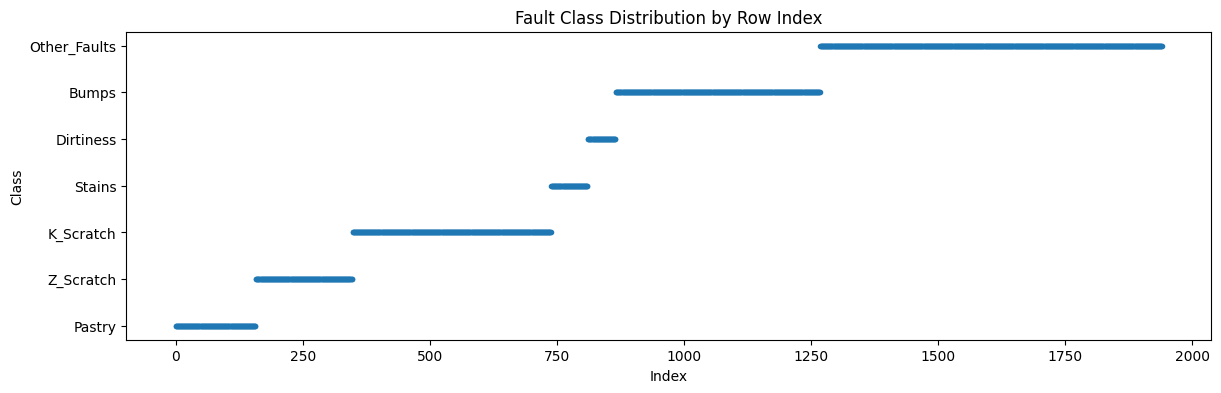

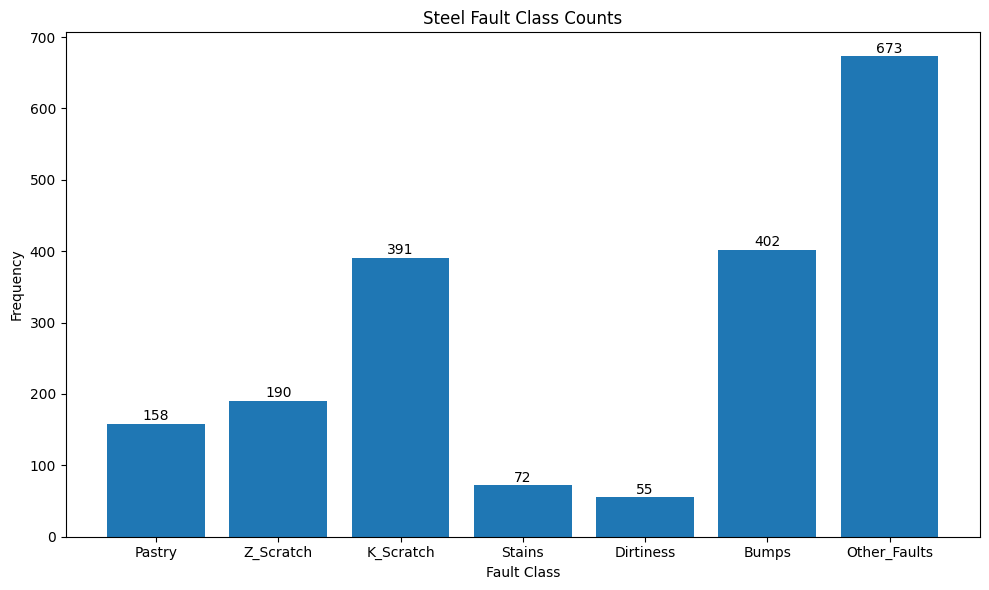

In [4]:
# ==============================================================================
# 2. Quick Dataset Overview (Plots remain for initial data understanding)
# ==============================================================================
print("\n--- Data Summary ---")
print(steel_data.describe())
print(steel_data.head())
print(steel_data.info())

label_series = steel_data[steel_data.columns[-7:]].idxmax(axis=1)
plt.figure(figsize=(14, 4))
plt.plot(label_series.reset_index(drop=True), marker='.', linestyle='none')
plt.title('Fault Class Distribution by Row Index')
plt.ylabel('Class')
plt.xlabel('Index')
plt.savefig("plots/fault_class_distribution.svg", format="svg") # Save plot
plt.show()

class_counts = steel_data[steel_data.columns[-7:]].sum()
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.index, class_counts.values)
plt.title('Steel Fault Class Counts')
plt.xlabel('Fault Class')
plt.ylabel('Frequency')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             int(bar.get_height()), ha='center')
plt.tight_layout()
plt.savefig("plots/fault_class_counts.svg", format="svg") # Save plot
plt.show()

## 3. Feature and Label Separation & Initial Train/Test Split

Features (`X`) and labels (`y`) are separated. The one-hot encoded labels are converted to a flat integer array. An initial train/test split is performed, with the test set held out to ensure an unbiased final evaluation.

In [5]:
# ==============================================================================
# 3. Feature and Label Separation & Initial Train/Test Split
# ==============================================================================
# Separate features (X) and one-hot encoded labels (y_onehot)
X = steel_data.iloc[:, :-7]
y_onehot = steel_data.iloc[:, -7:]
# Convert one-hot encoded labels to flat integer labels for classification
y_flat = np.argmax(y_onehot.values, axis=1)

# Perform the initial train/test split on the raw data.
# This ensures the test set remains completely untouched during tuning/selection.
X_train, X_test, y_train_flat, y_test_flat = train_test_split(
    X, y_flat, test_size=0.3, random_state=23, stratify=y_flat # Stratify for balanced classes
)

print(f"\nTraining set shape: {X_train.shape}, {y_train_flat.shape}")
print(f"Test set shape: {X_test.shape}, {y_test_flat.shape}")


Training set shape: (1358, 27), (1358,)
Test set shape: (583, 27), (583,)


## 4. Optimal KNN Hyperparameter Tuning and Feature Selection with Pipeline

This section defines a scikit-learn `Pipeline` that chains `StandardScaler`, `SelectKBest` (for feature selection), and `KNeighborsClassifier`. `GridSearchCV` is then used to simultaneously tune the hyperparameters of the KNN model and the feature selection step within a cross-validation framework. This prevents data leakage and finds the optimal combination for the best performance.

In [6]:
# ==============================================================================
# 4. Optimal KNN Hyperparameter Tuning and Feature Selection with Pipeline
# ==============================================================================
print("\n--- Optimal KNN Hyperparameter Tuning and Feature Selection ---")

# Define the pipeline: Scaling -> Feature Selection -> KNN Classifier
# The pipeline ensures that scaling and feature selection are applied correctly
# within each cross-validation fold during GridSearchCV.
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),                 # Step 1: Feature Scaling
    ('feature_selection', SelectKBest()),         # Step 2: Feature Selection (e.g., SelectKBest)
    ('knn', KNeighborsClassifier())               # Step 3: K-Nearest Neighbors Classifier
])

# Define the parameter grid for GridSearchCV.
# Parameters for pipeline steps are prefixed with their step name and double underscores.
param_grid = {
    # Parameters for SelectKBest (feature_selection step)
    'feature_selection__k': [5 ,7 , 10, 20, 27, X_train.shape[1] // 2, X_train.shape[1]], # Number of features to select
    'feature_selection__score_func': [f_classif, mutual_info_classif], # Scoring functions for feature selection

    # Parameters for KNeighborsClassifier (knn step)
    'knn__n_neighbors': [2*i+1 for i in range(1,12)], # Number of neighbors (k)
    'knn__weights': ['uniform', 'distance'],     # Weighting function used in prediction
    'knn__metric': ['euclidean', 'manhattan']    # Distance metric
}

# Initialize GridSearchCV with the pipeline and parameter grid.
# cv=5 means 5-fold cross-validation will be performed on the training data.
# n_jobs=-1 uses all available CPU cores for faster computation.
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy', # Metric to optimize during the search
    n_jobs=-1,
    verbose=2           # Display progress
)

print(">>> Running GridSearchCV for optimal KNN model...")
# Fit GridSearchCV on the training data.
# All scaling, feature selection, and KNN training happens within the CV folds.
grid_search.fit(X_train, y_train_flat)

print("\n--- GridSearchCV Results ---")
print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# The best_estimator_ is the fitted pipeline with the optimal parameters
# for scaler, feature selection, and KNN.
best_knn_model = grid_search.best_estimator_

# Get the names of the features selected by the best model
# This extracts the SelectKBest step from the best pipeline and gets its selected features.
selected_feature_indices = best_knn_model.named_steps['feature_selection'].get_support(indices=True)
selected_features_names = X.columns[selected_feature_indices].tolist()
print(f"\nFeatures selected by the best model ({len(selected_features_names)}): {selected_features_names}")

# Display the best 'k' used
best_k_value = grid_search.best_params_['knn__n_neighbors']
print(f"Best 'k' (n_neighbors) used in the optimal KNN model: {best_k_value}")


--- Optimal KNN Hyperparameter Tuning and Feature Selection ---
>>> Running GridSearchCV for optimal KNN model...
Fitting 5 folds for each of 616 candidates, totalling 3080 fits
[CV] END feature_selection__k=5, feature_selection__score_func=<function f_classif at 0x11429e170>, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.0s
[CV] END feature_selection__k=5, feature_selection__score_func=<function f_classif at 0x10afce170>, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.0s
[CV] END feature_selection__k=5, feature_selection__score_func=<function f_classif at 0x152ce2170>, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.0s
[CV] END feature_selection__k=5, feature_selection__score_func=<function f_classif at 0x10f71e170>, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.0s
[CV] END feature_selection__k=5, feature_selection__score_func=<function f_classif

## 5. Final Evaluation on the Untouched Test Set

The optimal KNN model (the `best_estimator_` from GridSearchCV) is evaluated on the completely untouched test set to provide an unbiased estimate of its generalization performance. A confusion matrix is also displayed, along with class-wise accuracy rates.

In [7]:
# # ==============================================================================
# # 5. Final Evaluation on the Untouched Test Set
# # ==============================================================================
# print("\n--- Final Model Evaluation on Test Set ---")
# # Predict on the untouched test set using the best_knn_model.
# # The pipeline automatically handles scaling and feature selection on X_test.
# y_pred_test = best_knn_model.predict(X_test)

# # Calculate overall accuracy
# test_accuracy = accuracy_score(y_test_flat, y_pred_test)
# print(f"Final KNN Model Test Accuracy: {test_accuracy:.4f}")

# # Generate and display the confusion matrix for the test set
# cm = confusion_matrix(y_test_flat, y_pred_test, normalize='true')
# class_names = steel_data.columns[-7:].tolist() # Get class names from original data

# fig, ax = plt.subplots(figsize=(8, 6))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt=".3f",
#     cmap="Blues",
#     cbar=False,
#     square=True,
#     ax=ax,
#     linewidths=0,
#     annot_kws={"fontsize": 10},
#     xticklabels=class_names,
#     yticklabels=class_names
# )

# # Replace 0.00 with '0' for better readability
# for text in ax.texts:
#     if text.get_text() == '0.000': # Adjust for fmt=".3f"
#         text.set_text('0')

# plt.title("Optimal KNN Confusion Matrix (Normalized) - Test Set", fontsize=14)
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.tight_layout()
# plt.savefig("plots/optimal_knn_confusion_matrix.svg", format="svg") # Save plot
# plt.show()

# # Calculate and display class-wise average classification rates
# print("\n--- Class-wise Average Classification Rates ---")
# class_accuracies = {}
# all_over_90 = True
# for i, class_name in enumerate(class_names):
#     class_accuracy = cm[i, i] # Diagonal elements of normalized CM are class-wise recall/accuracy
#     class_accuracies[class_name] = class_accuracy
#     print(f"  Class '{class_name}': {class_accuracy:.4f}")
#     if class_accuracy < 0.90:
#         all_over_90 = False

# if all_over_90:
#     print("\nAll class-wise average classification rates are over 90% (0.90)!")
# else:
#     print("\nSome class-wise average classification rates are NOT over 90% (0.90).")

## 6. Accuracy Bar Plot

A simple bar plot visualizing the final test accuracy of the optimal KNN model.

In [8]:
# ==============================================================================
# 6. Accuracy Bar Plot (Optional, for comparison if other models were added)
# ==============================================================================
plt.figure(figsize=(6, 4))
plt.bar(["Optimal KNN"], [test_accuracy], color=["skyblue"])
plt.ylim(0, 1)
plt.ylabel("Mean Class Accuracy")
plt.text(0, test_accuracy + 0.02, f"{test_accuracy:.2f}", ha='center')
plt.title("Optimal KNN Test Accuracy")
plt.tight_layout()
plt.savefig("plots/optimal_knn_accuracy_bar.svg", format="svg") # Save plot
plt.show()

NameError: name 'test_accuracy' is not defined

<Figure size 600x400 with 0 Axes>

## 7. Pairwise Scatter Plots (Using the features selected by the optimal model)

Generates scatter plots for pairs of the features that were selected by the optimal model, helping to visualize relationships and class separation in the reduced feature space.

In [9]:
selected_features_names = ['Pixels_Areas', 'Steel_Plate_Thickness', 'Length_of_Conveyer', 'Y_Minimum', 'TypeOfSteel_A300', 'Outside_X_Index']

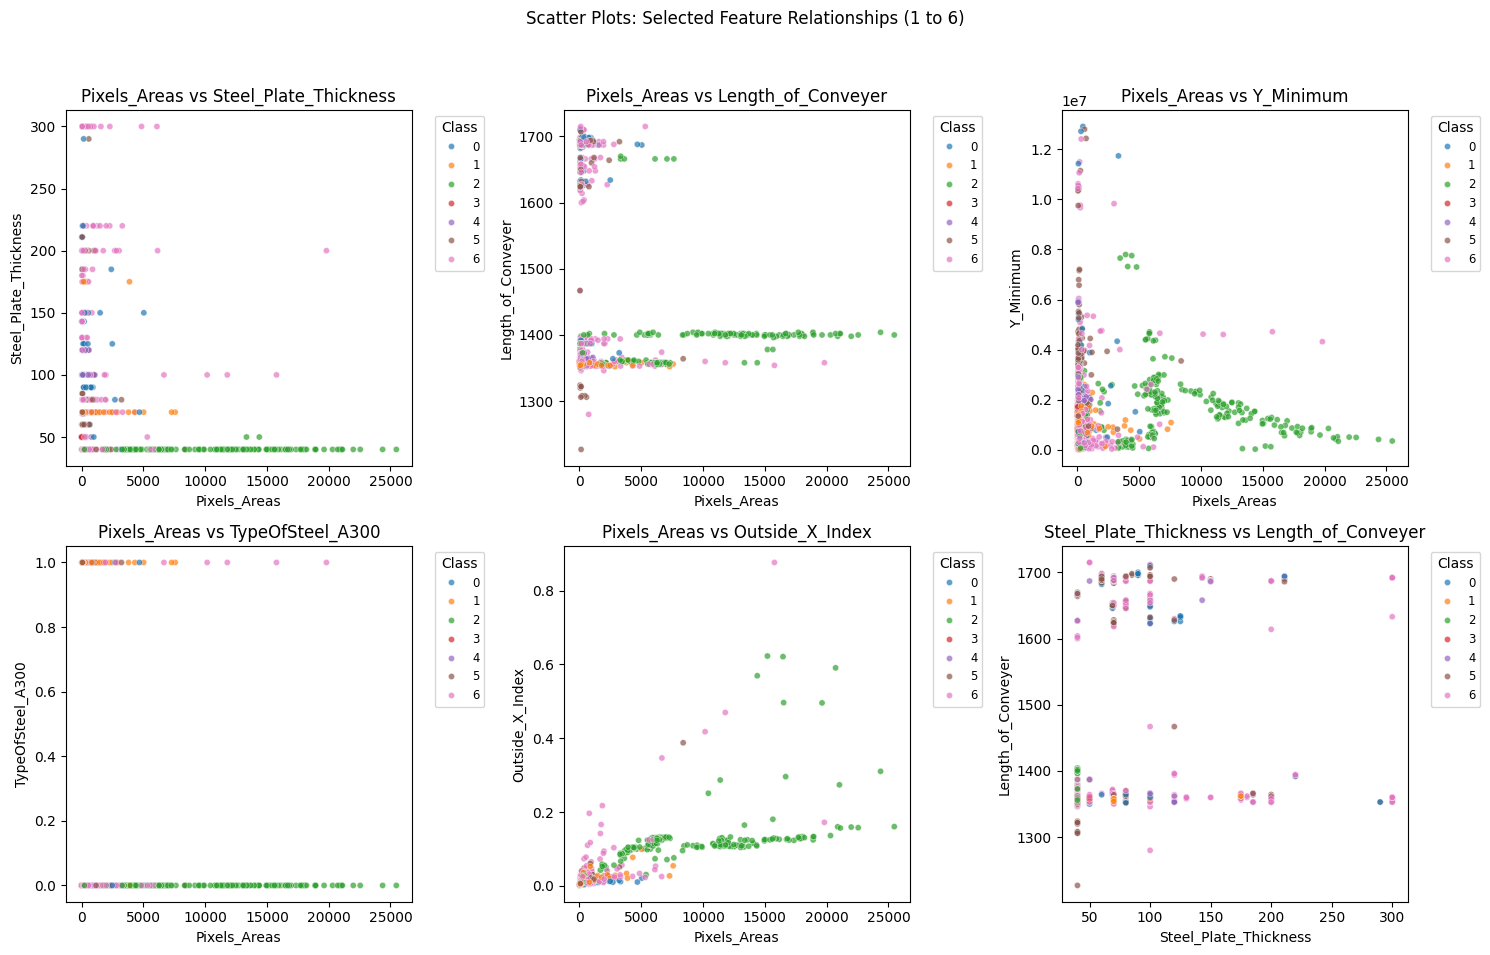

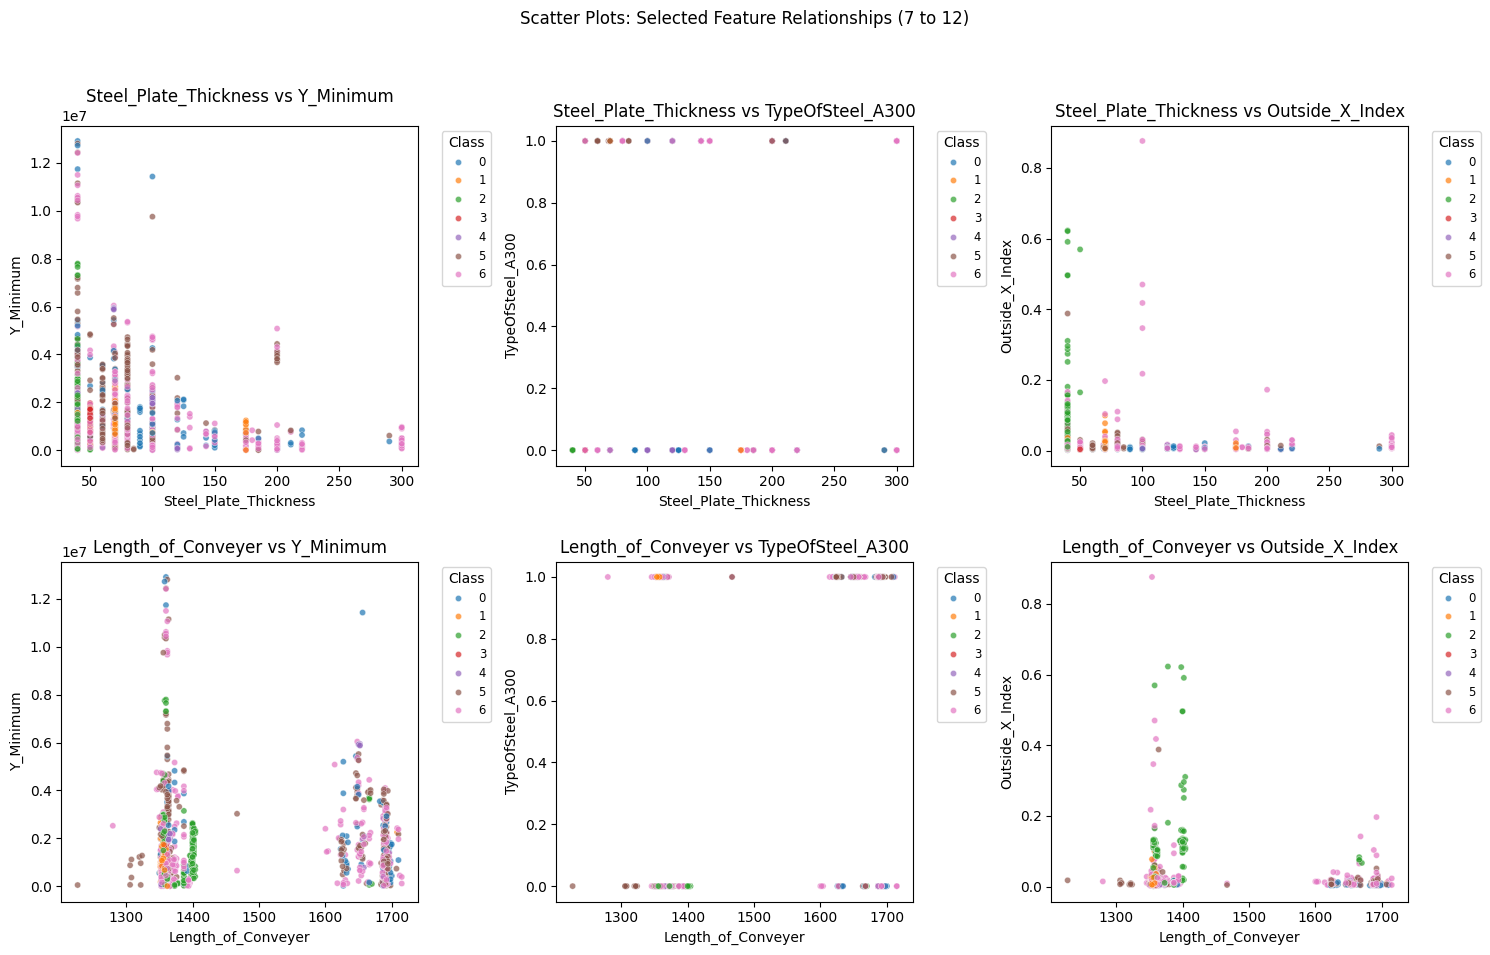

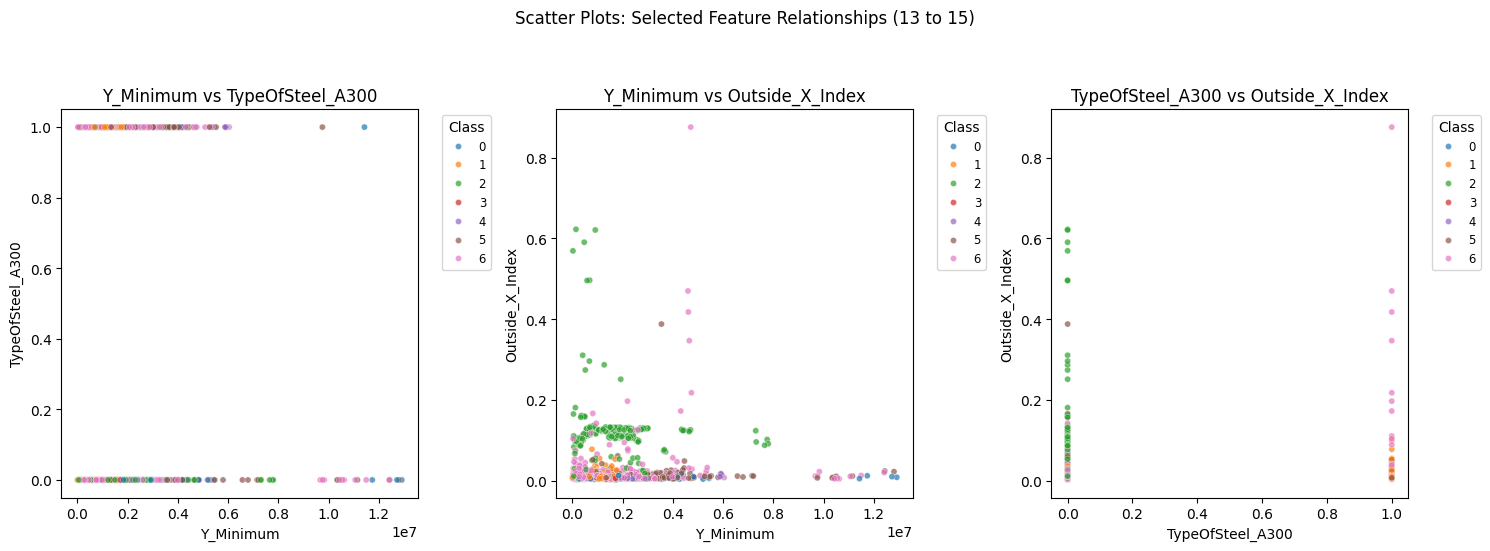

In [10]:
# ==============================================================================
# 7. Pairwise Scatter Plots (Using the features selected by the optimal model)
# ==============================================================================
# Use the X_train (original, unscaled) to get the selected features for plotting
X_train_selected_for_plot = X_train[selected_features_names]

feature_pairs = list(combinations(selected_features_names, 2))
plots_per_fig = 6 # Max 6 plots per figure for readability

if feature_pairs: # Only plot if there are at least two selected features
    for i in range(0, len(feature_pairs), plots_per_fig):
        subset = feature_pairs[i:i + plots_per_fig]
        plt.figure(figsize=(15, 10))

        for j, (f1, f2) in enumerate(subset):
            plt.subplot(2, 3, j + 1)
            # Use original data for plotting, colored by flat labels
            sns.scatterplot(x=f1, y=f2, hue=y_train_flat, data=X_train_selected_for_plot, palette='tab10', alpha=0.7, s=20)
            plt.xlabel(f1)
            plt.ylabel(f2)
            plt.title(f"{f1} vs {f2}")
            plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

        plt.suptitle(f"Scatter Plots: Selected Feature Relationships ({i + 1} to {i + len(subset)})")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"plots/selected_features_scatter_plots_{i+1}_to_{i+len(subset)}.svg", format="svg") # Save plot
        plt.show()
else:
    print("Not enough selected features for pairwise scatter plots (need at least 2).")

## 8. Boxplots by Class (Using the features selected by the optimal model)

Creates boxplots for each of the selected features, showing their distribution across different fault classes. This helps to understand how well each selected feature separates the classes.

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


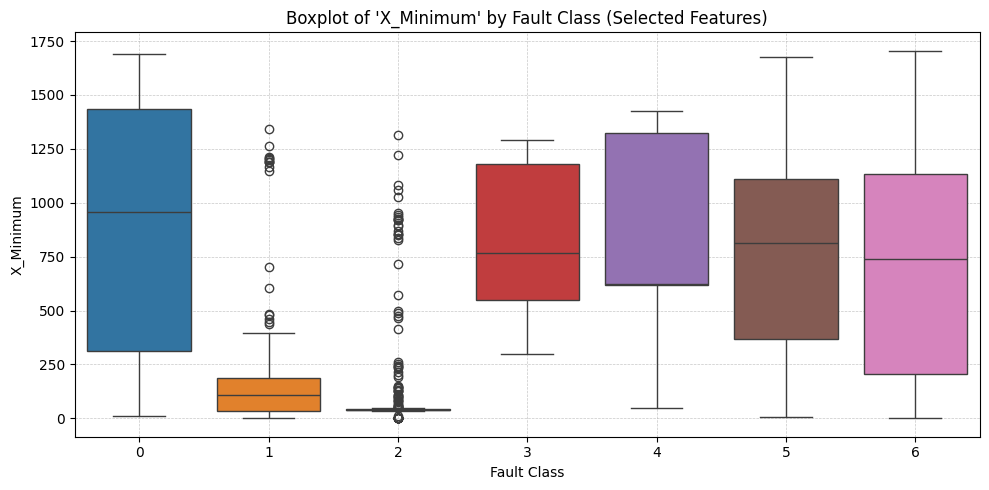

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


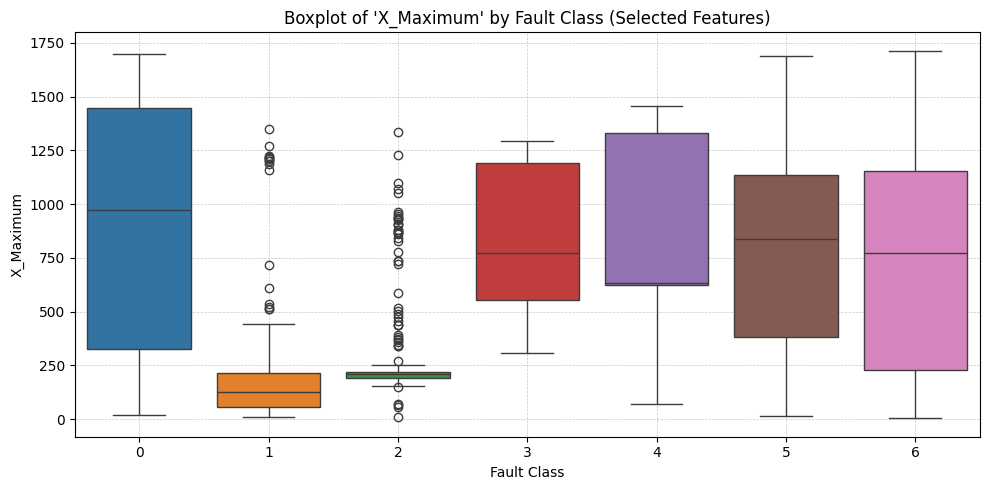

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


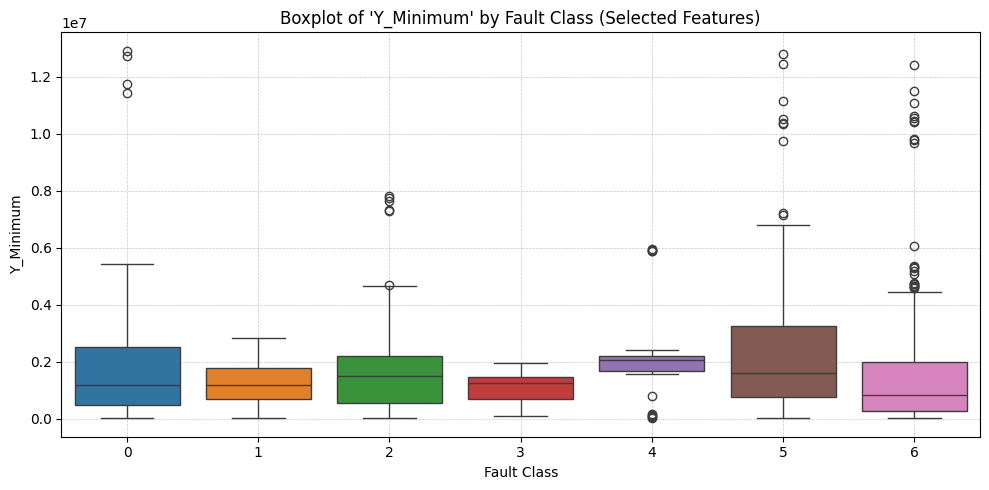

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


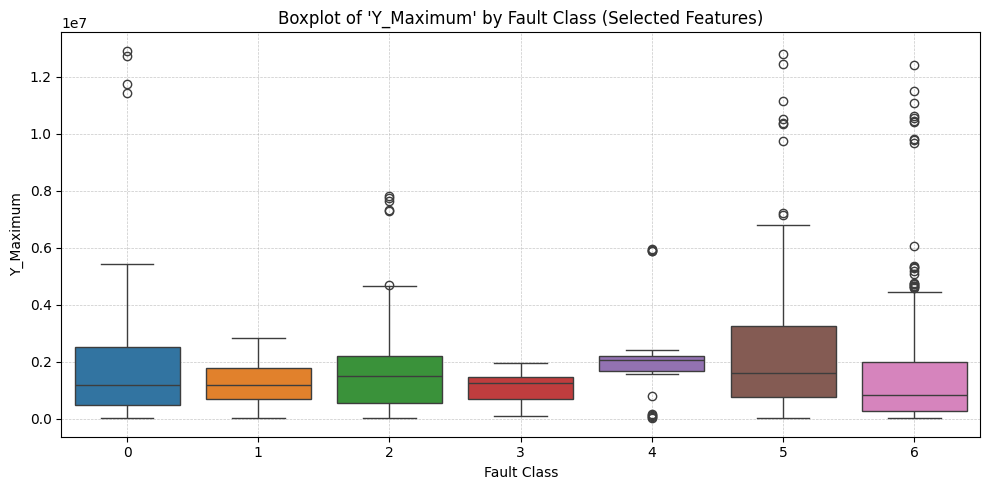

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


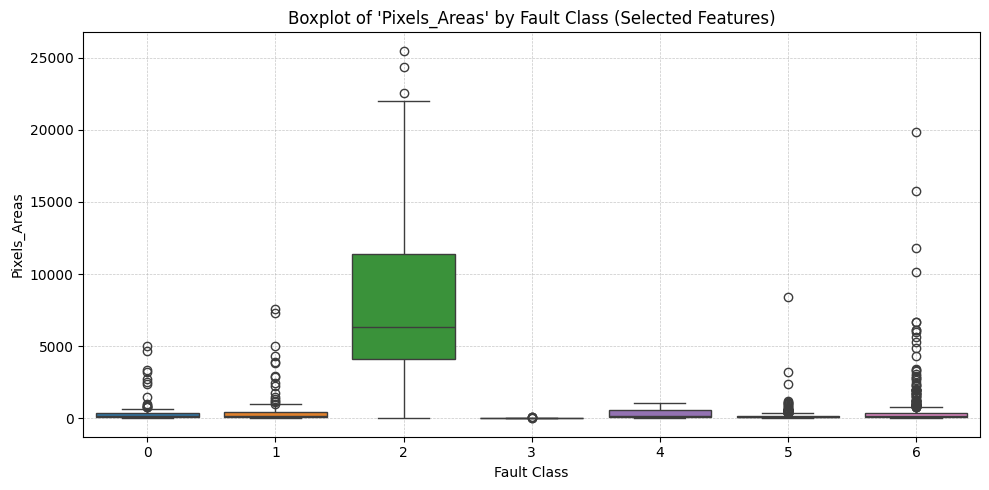

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


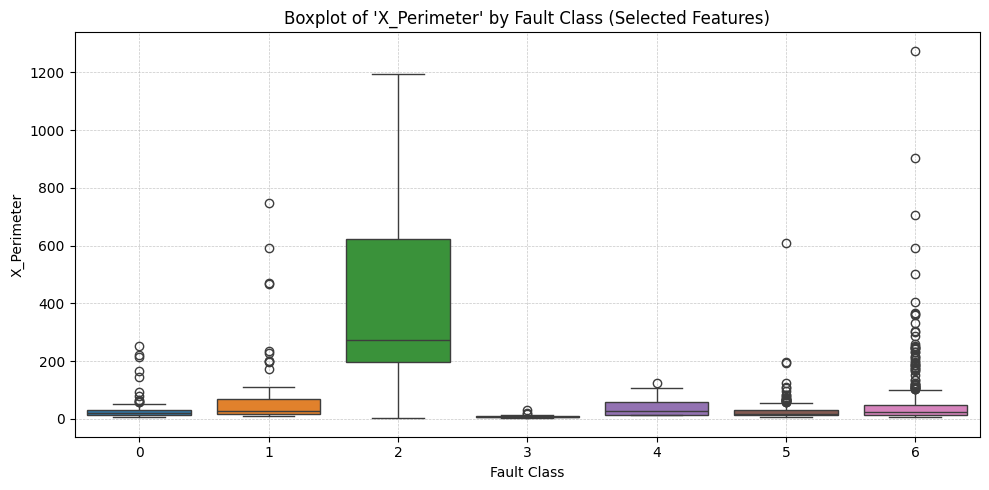

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


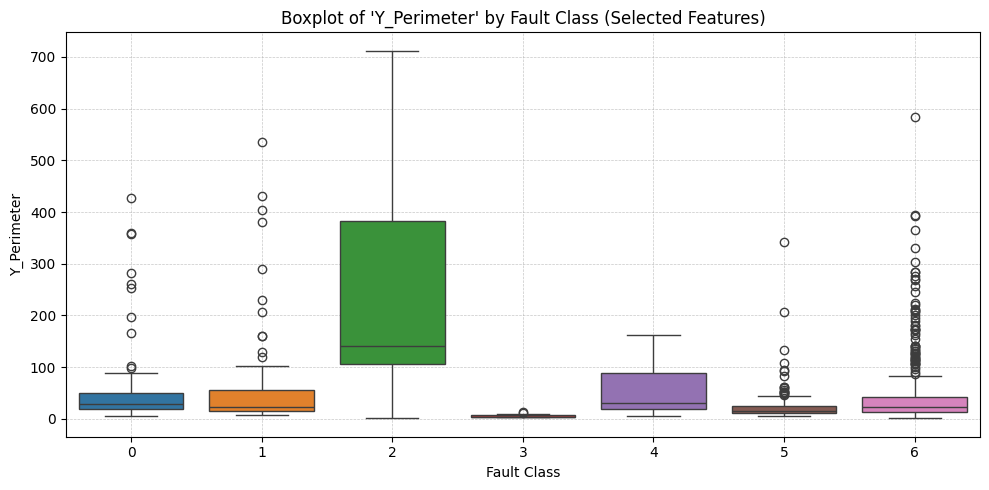

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


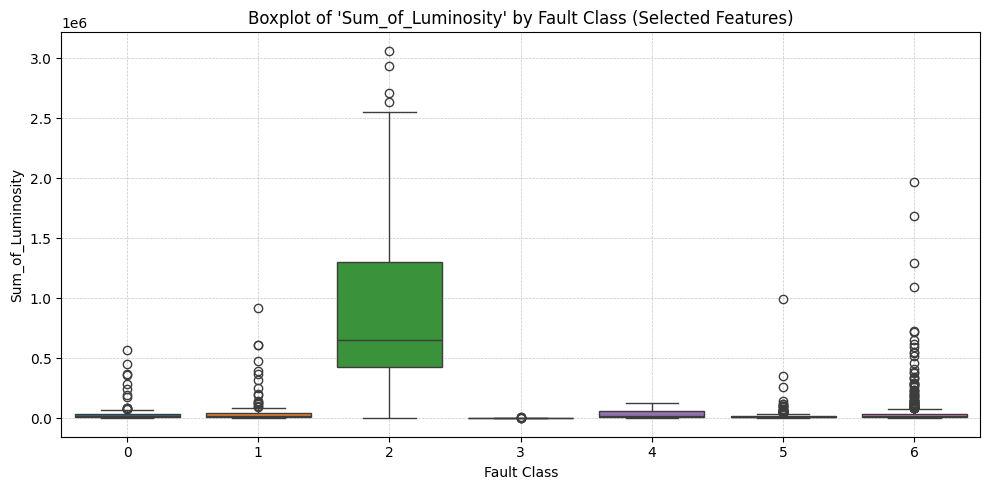

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


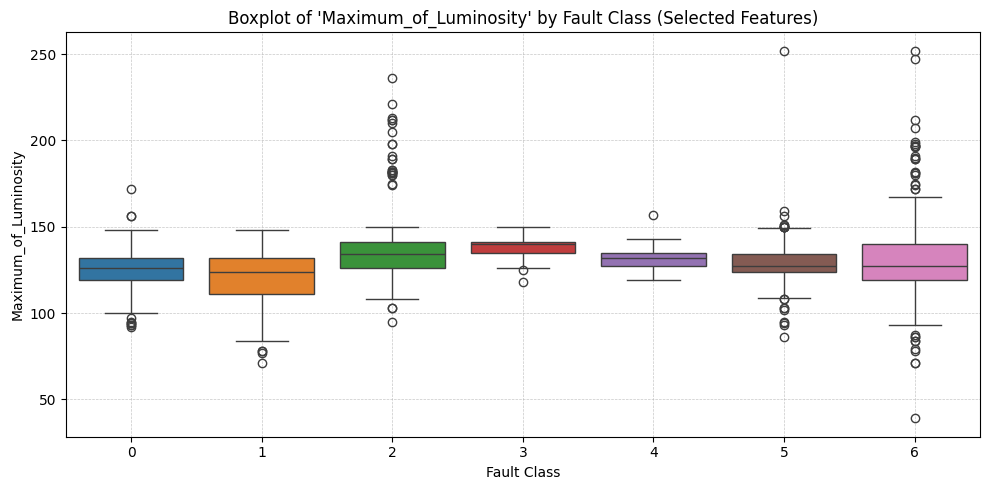

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


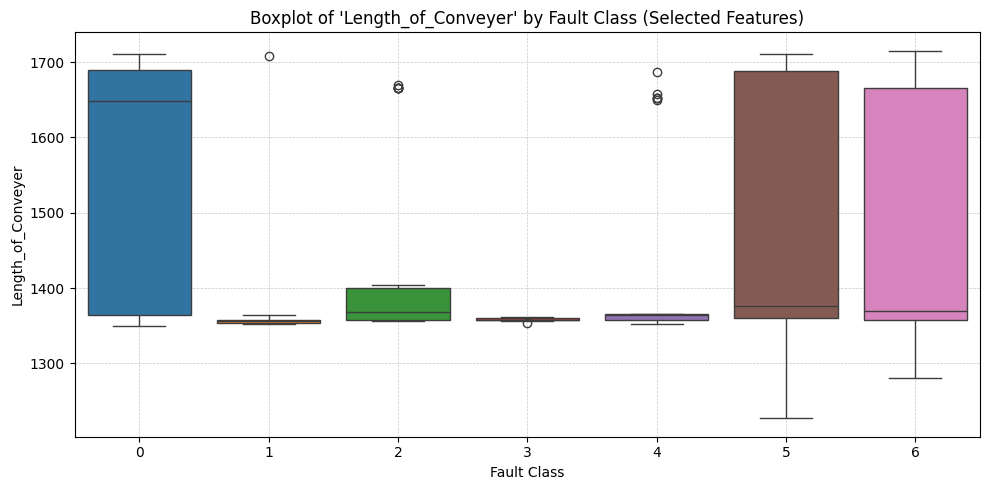

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


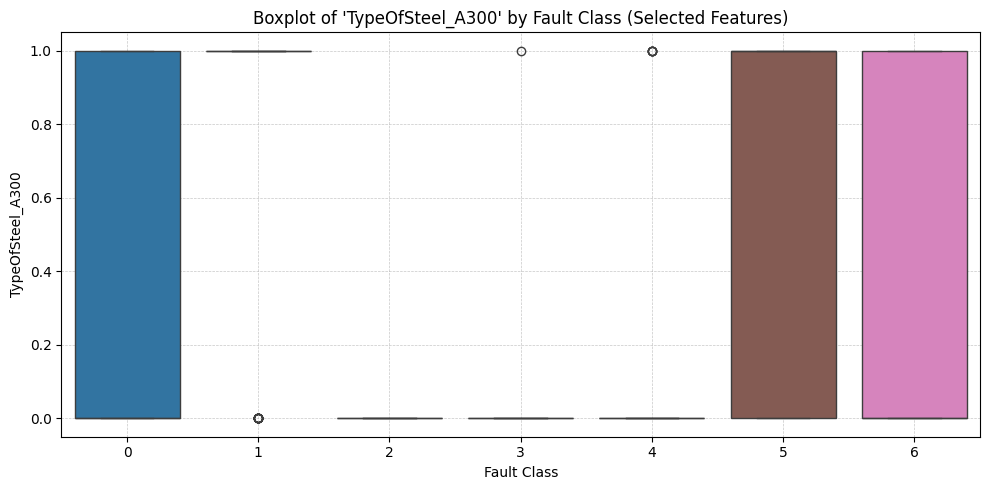

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


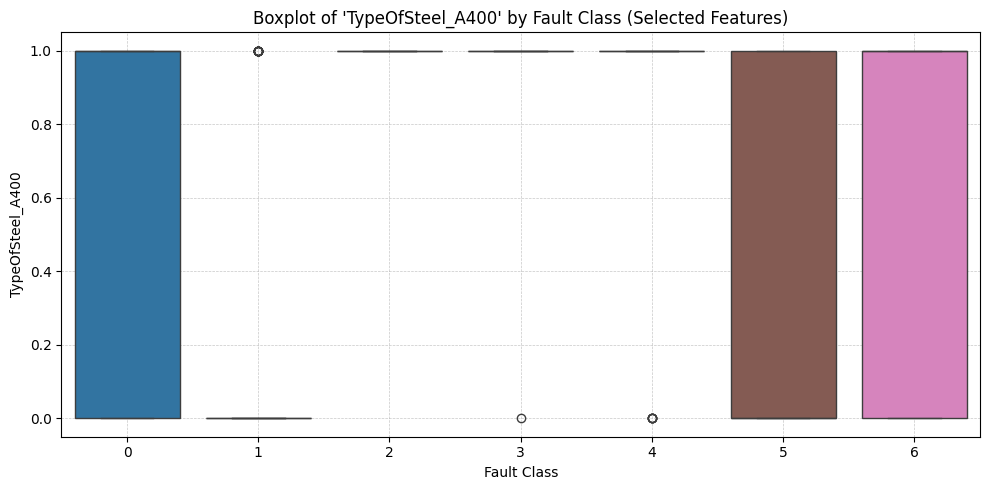

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


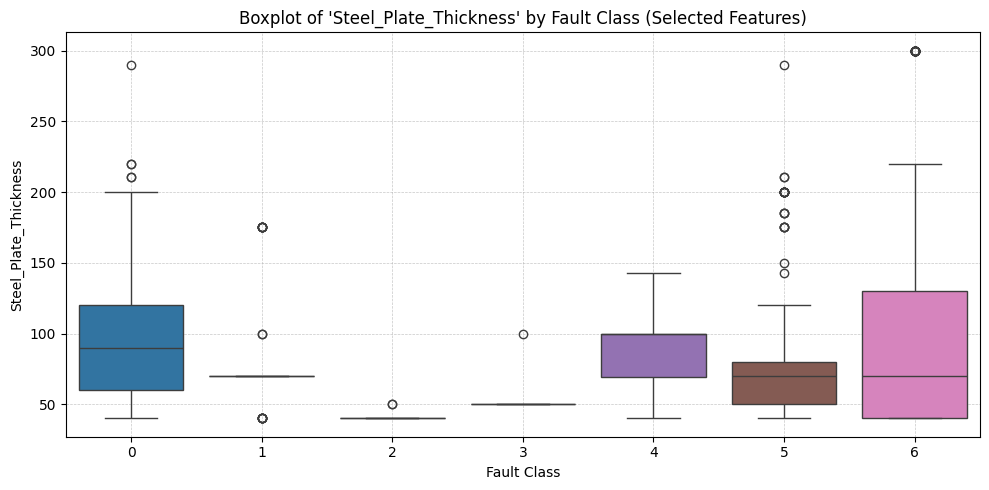

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


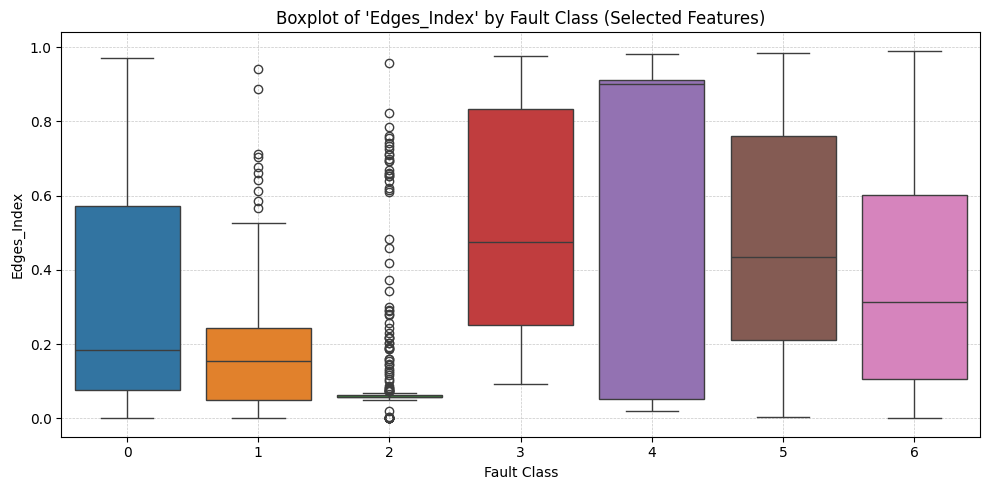

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


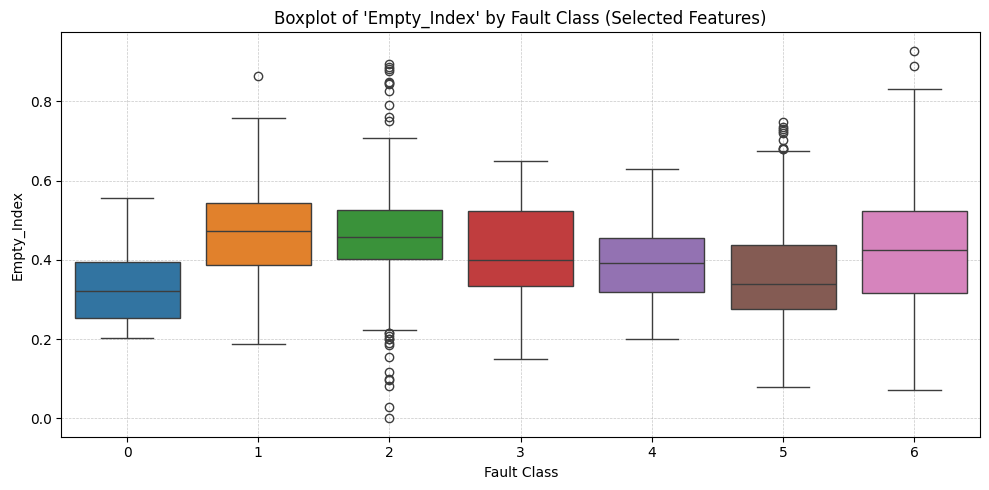

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


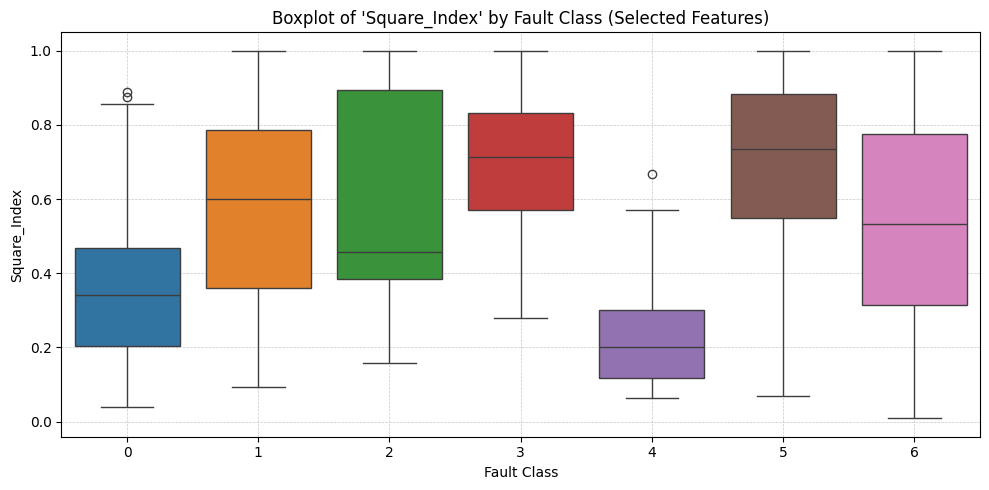

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


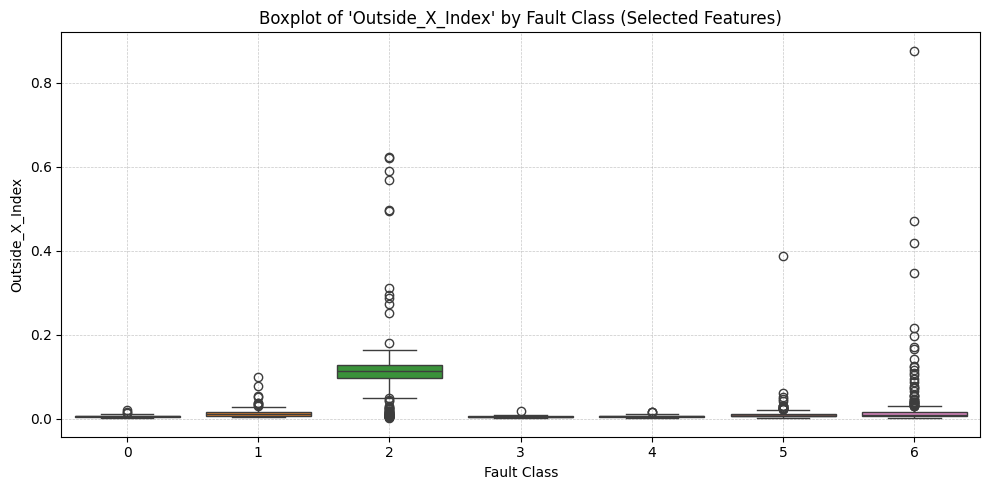

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


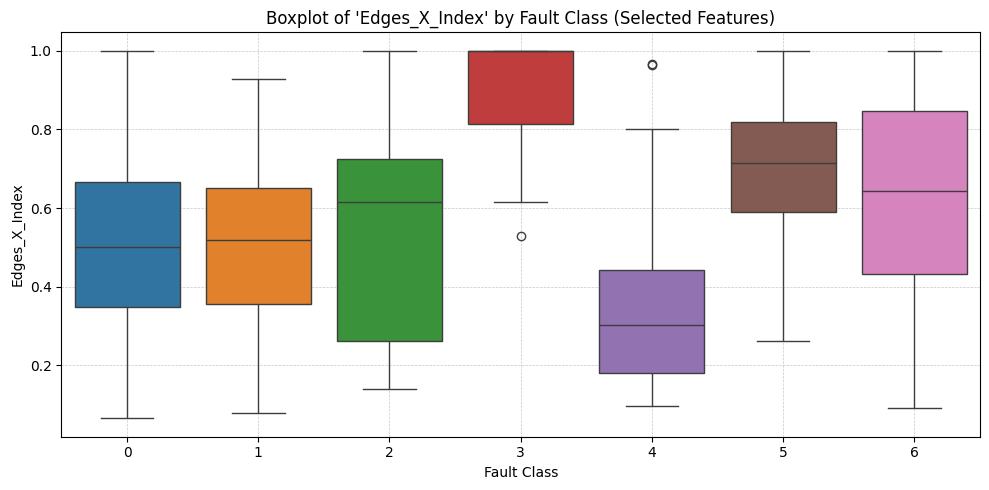

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


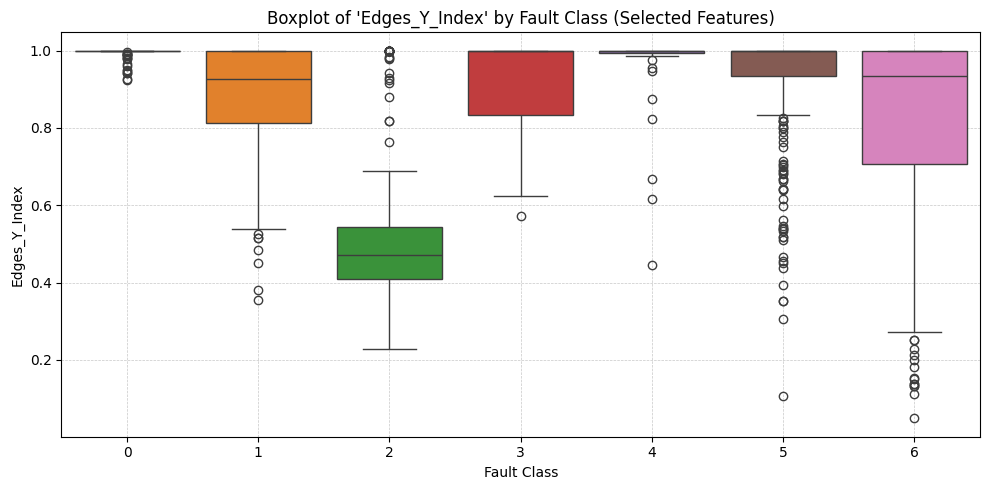

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


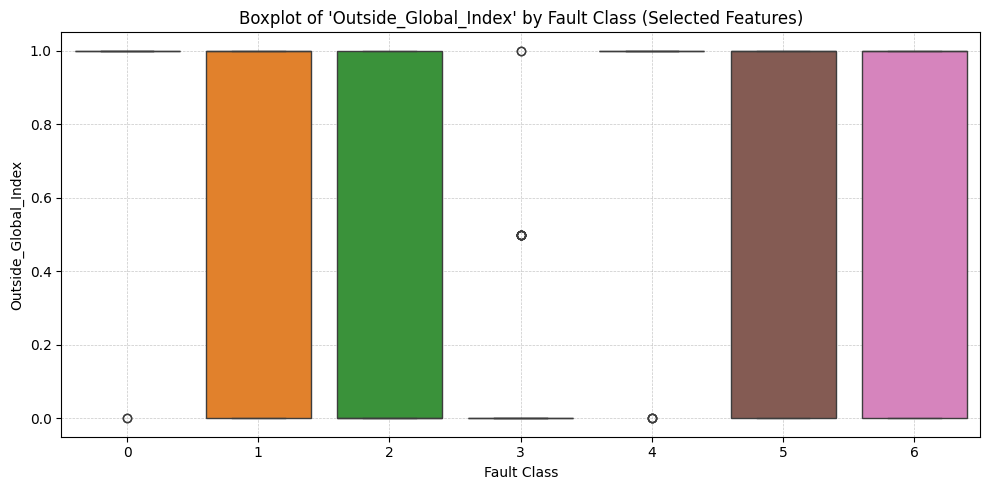

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


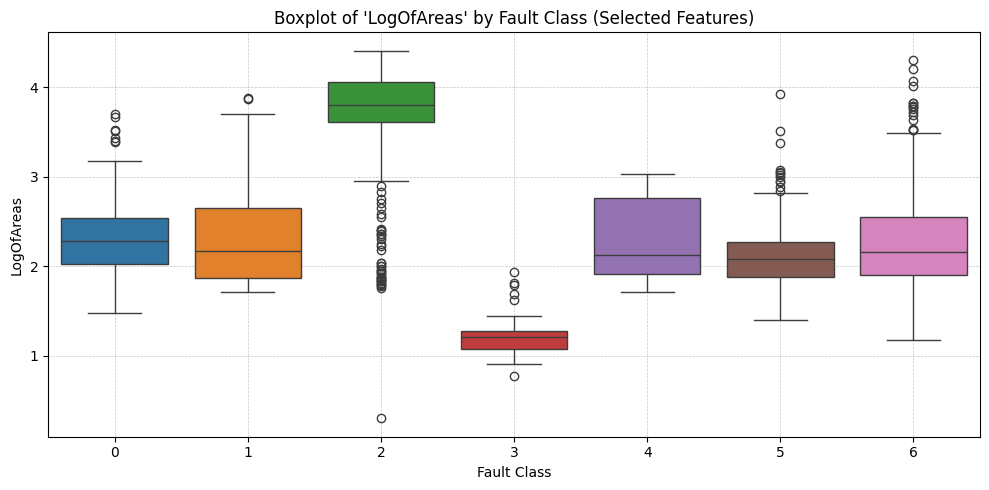

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


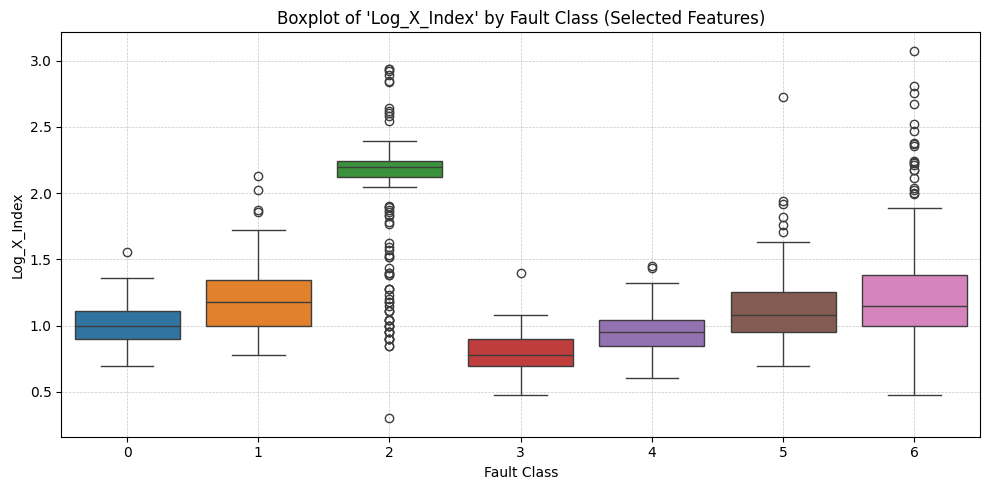

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


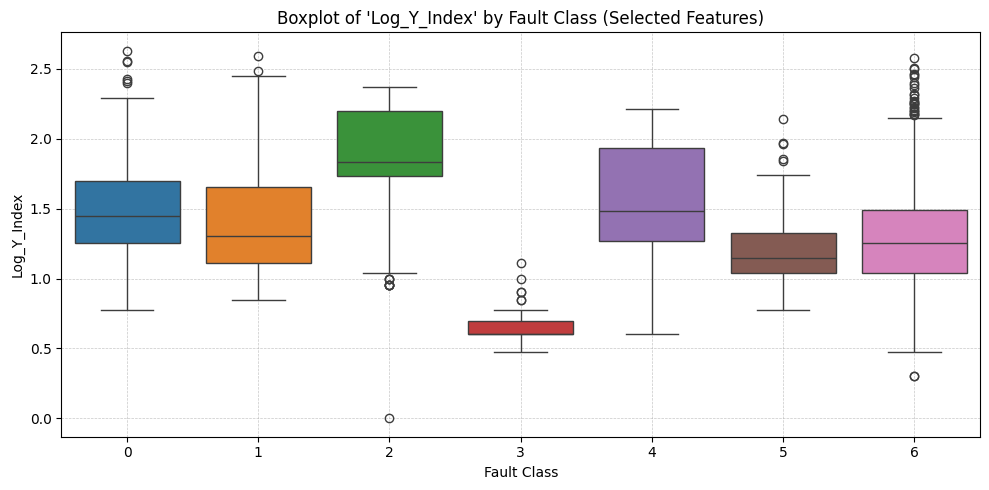

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


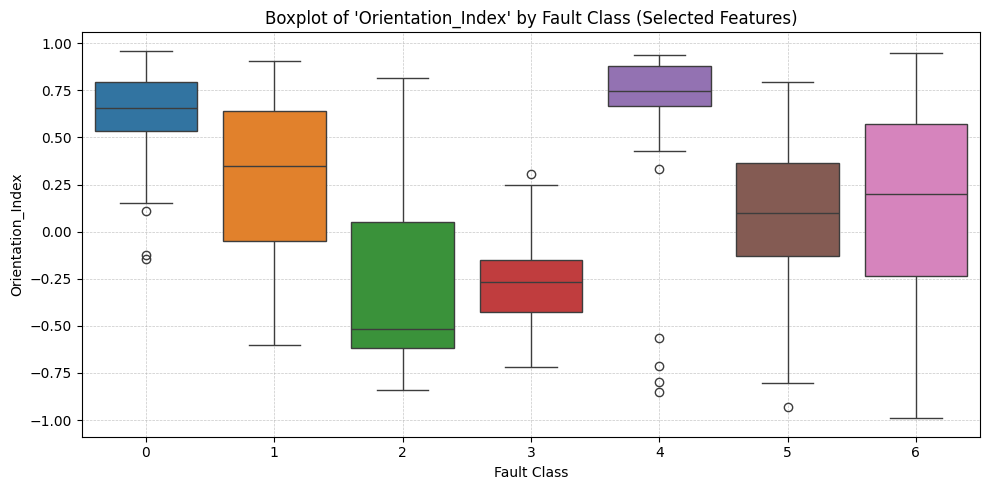

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


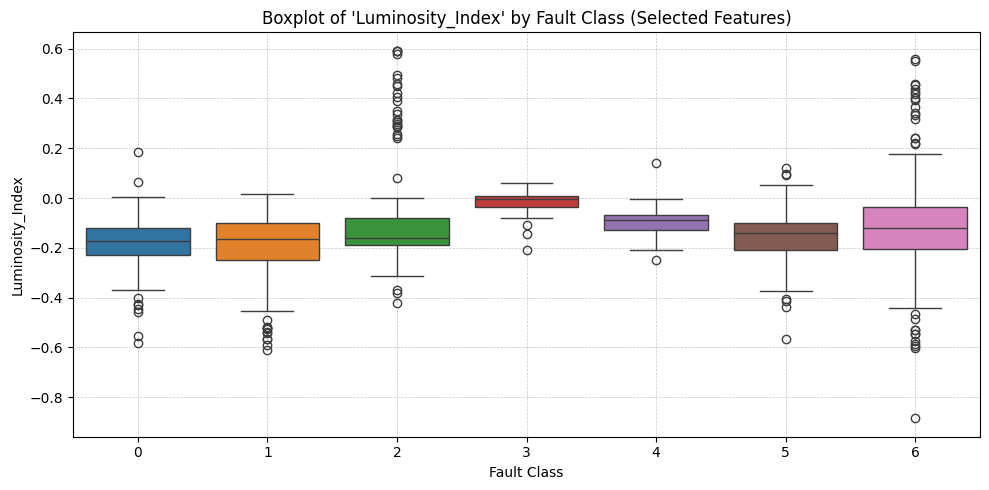

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


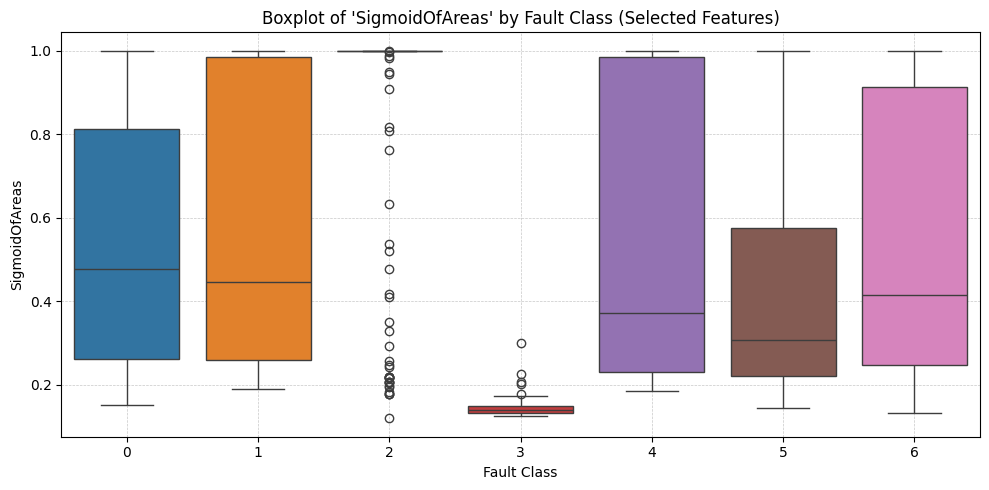

C:\Users\jamal\AppData\Local\Temp\ipykernel_19480\884549148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette


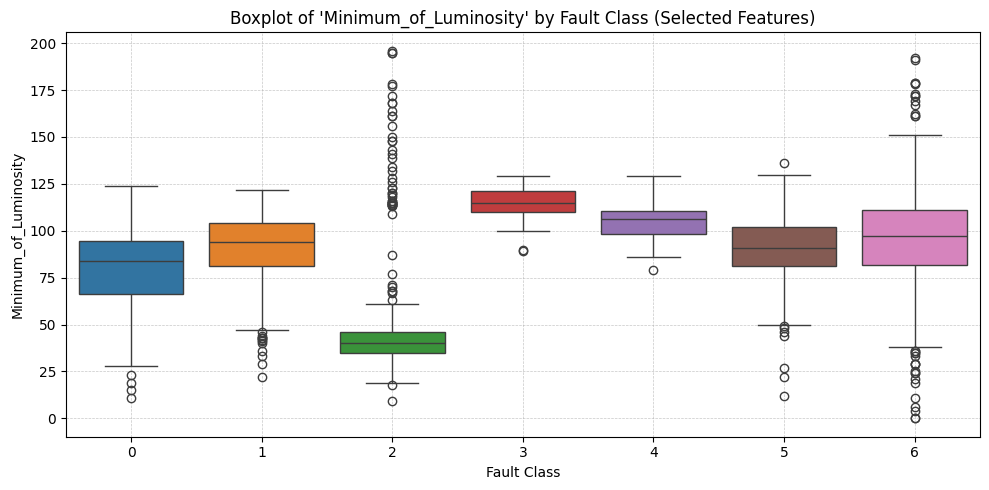

In [ ]:
# ==============================================================================
# 8. Boxplots by Class (Using the features selected by the optimal model)
# ==============================================================================
# Create a DataFrame for plotting, including only selected features and the flat labels
plot_df = X_train[selected_features_names].copy()
plot_df['Class'] = y_train_flat

if selected_features_names: # Only plot if there are selected features
    for feat in selected_features_names:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x='Class', y=feat, data=plot_df, palette='tab10') # Use a color palette
        plt.title(f"Boxplot of '{feat}' by Fault Class (Selected Features)")
        plt.xlabel("Fault Class")
        plt.ylabel(feat)
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        plt.tight_layout()
        plt.savefig(f"plots/selected_features_boxplot_by_class_{feat}.svg", format="svg") # Save plot
        plt.show()
else:
    print("No features selected for boxplots.")